In [ ]:
import pandas as pd
import jax
from arviz.labels import MapLabeller

import sys
import os
sys.path.append(os.path.abspath(os.path.join('../..')))

from utils.modeling import (
    encode_categorical_covariates, 
    fit_model_and_extract_idata
    )

from utils.plotting import (
    plot_predictive_distributions,
    plot_combined_figure_single,
    plot_model_comparison
)

/home/ubuntu/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get data

In [2]:
df = pd.read_csv('data.csv')
# Check
print('Unique graders:', set(df['grader']))
print('Unique models:', set(df['LLM']))
df.head(5)

Unique graders: {'Human', 'Autograder'}
Unique models: {'LLM A'}


,score,grader,LLM
0,8,Human,LLM A
1,7,Human,LLM A
2,5,Human,LLM A
3,6,Human,LLM A
4,8,Human,LLM A


# Fit model

In [3]:
# Define covariates and outcome
main_effects = ['grader']  # categorical variables
interactions = None
outcome = 'score'  # ordinal variable, 0–10

# Encode categorical covariates
covariates_dict, category_maps = encode_categorical_covariates(df, main_effects)

# Encore the outcome
allowed_scores = list(range(11))  # ordinal values: 0–10
score_map = {val: i for i, val in enumerate(allowed_scores)}
y = df[outcome].map(score_map).values

# Fit model
rng_key = jax.random.PRNGKey(0)
mcmc, idata = fit_model_and_extract_idata(
    rng_key, 
    covariates_dict, 
    y, 
    main_effects, 
    interactions, 
    category_maps
)

sample: 100%|██████████| 2000/2000 [00:03<00:00, 633.79it/s, 15 steps of size 1.97e-01. acc. prob=0.93]


In [4]:
# Define covariates and outcome
main_effects = ['grader']  # categorical variables
interactions = None
outcome = 'score'  # ordinal variable, 0–10

# Encode categorical covariates
covariates_dict, category_maps = encode_categorical_covariates(df, main_effects)

# Encore the outcome
allowed_scores = list(range(11))  # ordinal values: 0–10
score_map = {val: i for i, val in enumerate(allowed_scores)}
y = df[outcome].map(score_map).values

## Model with grader
mcmc_with_grader, idata_with_grader = fit_model_and_extract_idata(
    rng_key, covariates_dict, y, main_effects = ['grader'], 
    interactions=interactions, category_maps=category_maps
)

## Null model
mcmc_without_grader, idata_without_grader = fit_model_and_extract_idata(
    rng_key, covariates_dict, y, main_effects = [],
    interactions=interactions, category_maps=category_maps
)

sample: 100%|██████████| 2000/2000 [00:01<00:00, 1070.93it/s, 15 steps of size 2.12e-01. acc. prob=0.94]


# Fitted parameters

In [5]:
mcmc_with_grader.print_summary()


                       mean       std    median      5.0%     95.0%     n_eff     r_hat
      b_grader[0]     -1.66      0.18     -1.65     -1.97     -1.38    628.65      1.00
cutpoint_diffs[0]      0.58      0.17      0.55      0.32      0.85    968.76      1.00
cutpoint_diffs[1]      0.56      0.16      0.54      0.30      0.81    966.14      1.00
cutpoint_diffs[2]      0.69      0.19      0.67      0.38      0.97    890.74      1.00
cutpoint_diffs[3]      0.85      0.19      0.84      0.55      1.14    936.40      1.00
cutpoint_diffs[4]      1.30      0.21      1.29      0.94      1.61    993.01      1.00
cutpoint_diffs[5]      1.33      0.24      1.33      0.90      1.69    785.01      1.00
cutpoint_diffs[6]      1.25      0.19      1.24      0.94      1.55    959.80      1.00
cutpoint_diffs[7]      1.41      0.32      1.39      0.92      1.92   1005.55      1.00
cutpoint_diffs[8]      0.68      0.21      0.65      0.38      1.02    922.61      1.00
   first_cutpoint     -4.09    

# Model comparison

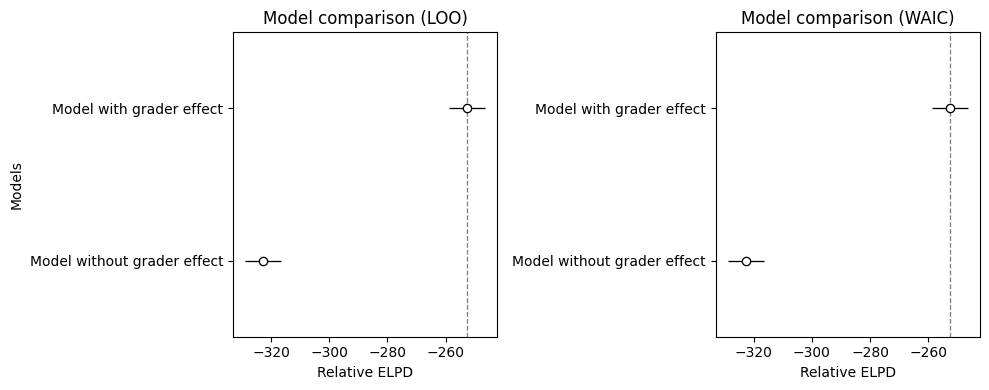

In [6]:
idata_dict = {
    "Model with grader effect": idata_with_grader,
    "Model without grader effect": idata_without_grader
}

plot_model_comparison(idata_dict, ylabel="Models", fig_path="../../figures/figure1c.png")

## Checks

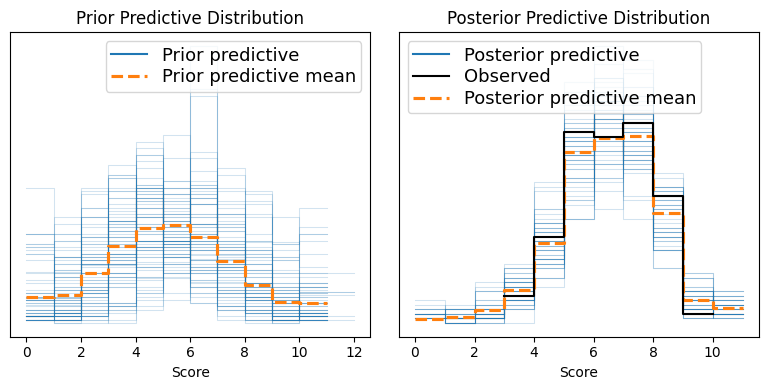

In [7]:
plot_predictive_distributions(idata, fig_path="fig_predictive.png")

# Figure

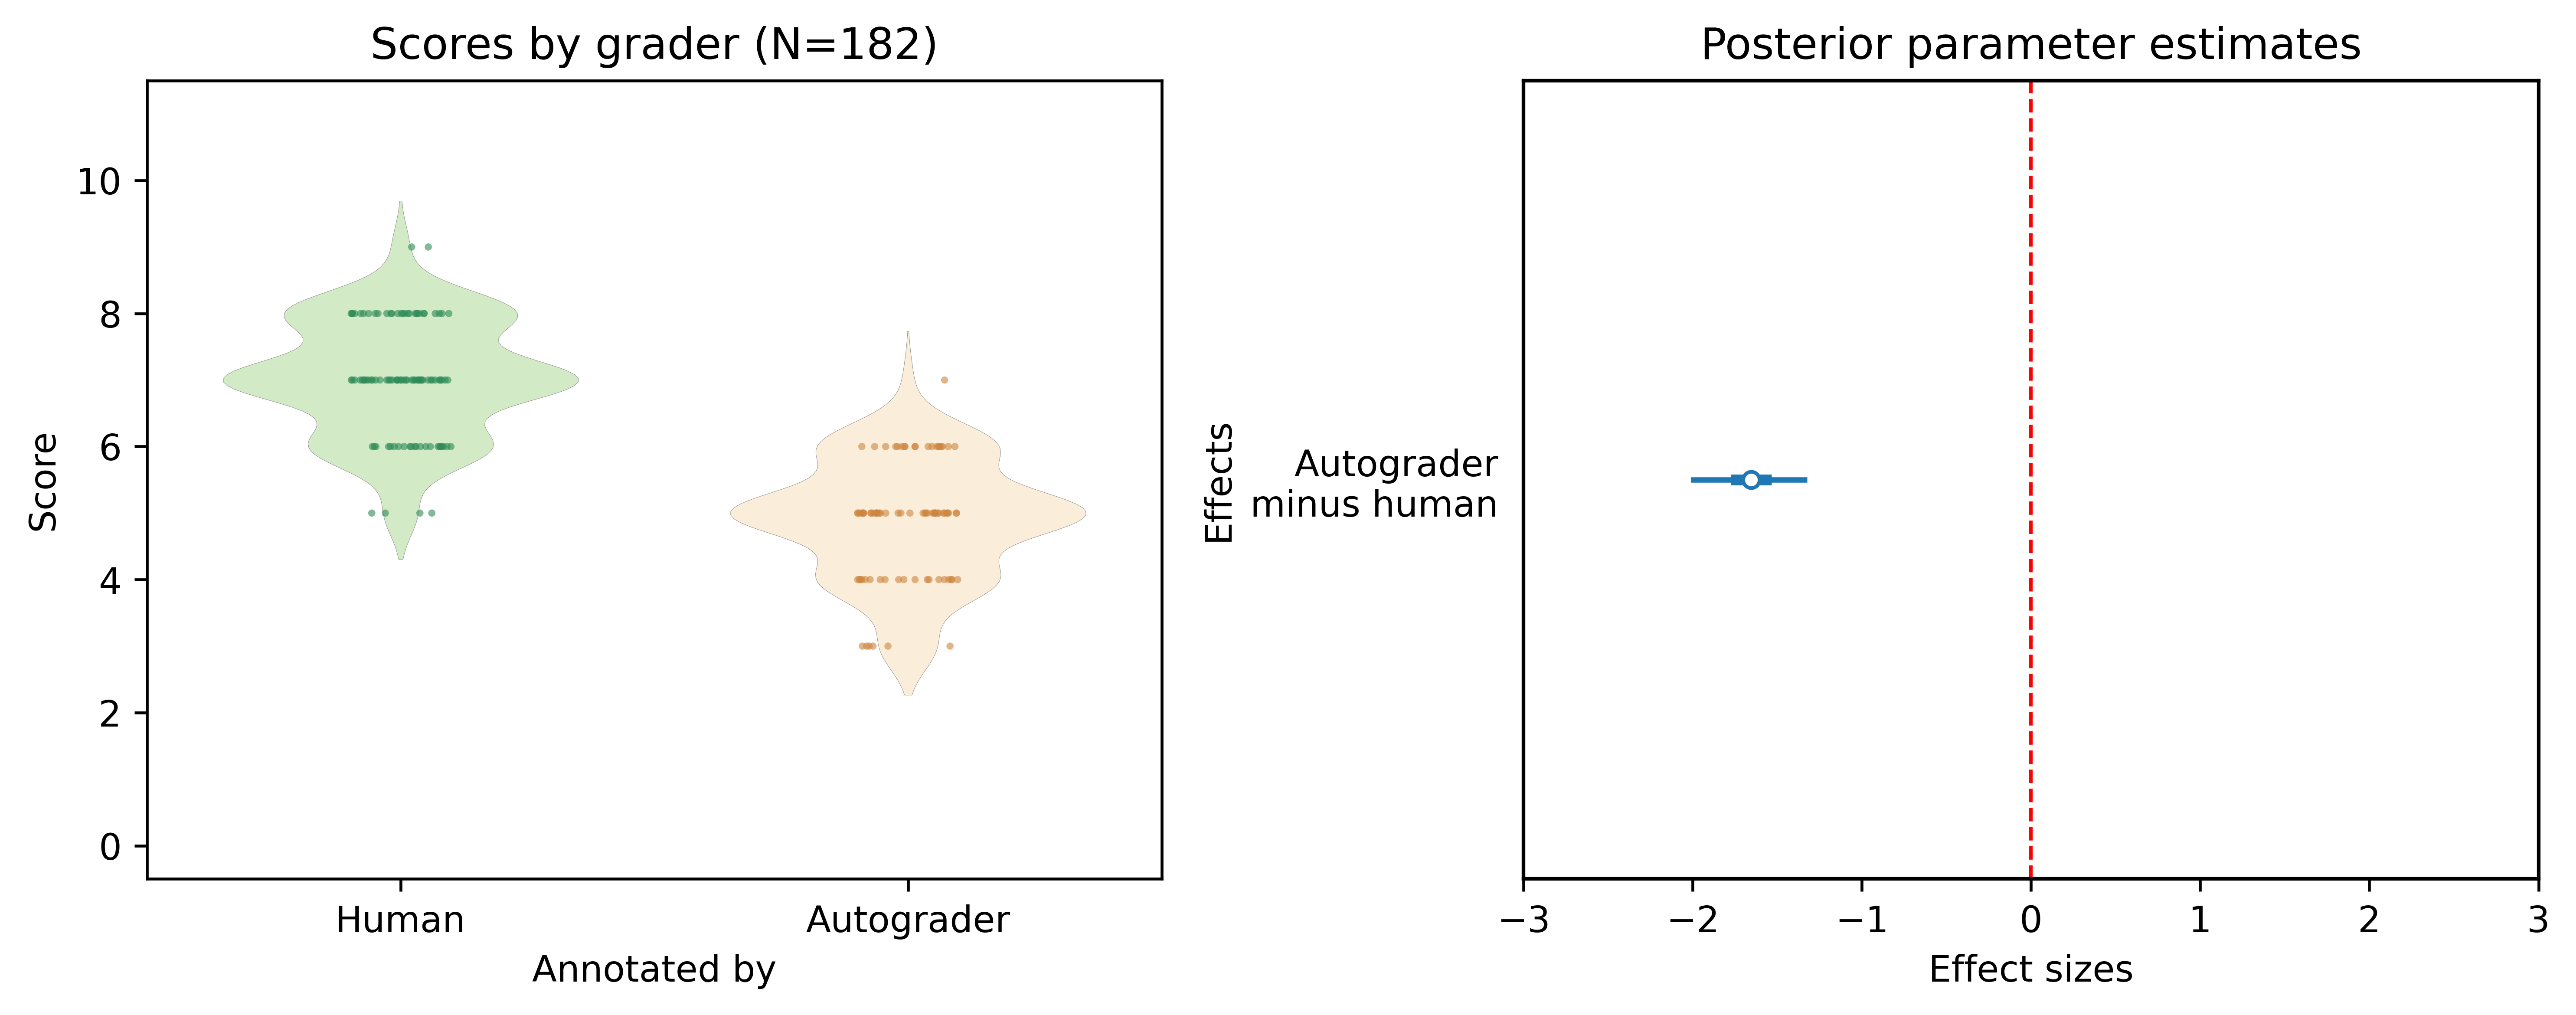

In [8]:
labeller = MapLabeller(
    var_name_map={
        "b_grader": "Autograder\nminus human",
    }
)

plot_combined_figure_single(df, idata, 
                     var_names=["b_grader"], 
                     labeller=labeller, 
                     color_scheme='1autograder',
                     fig_path="../../figures/figure1.png",
                     legend_title=None,
                     xlim=[-3, 3],
                     vertical_centering=True,
                     show_predictions=False,
                     category_maps=category_maps,
                     jitter_strength=0.15
                     )